# 11f — Net-zero pathway benchmarks

Covers `chap11_net_zero1a.m` through `net_zero1d.m` and `net_zero8.m`:
self-contained illustrations of global/sector emissions scenarios and
normalized decarbonization-pathway benchmarks (IEA scenario data, NZAOA/
CTB/PAB stylized targets), all built from hardcoded IEA-style data — no
external files. The smoothing-spline fits use MATLAB's `csaps(x,y,p,xi)`
(Spline Toolbox), reproduced here with the `csaps` Python package (a
direct, parameter-compatible port of the same algorithm — same `p` in
$[0,1]$, `p=0`: least-squares line, `p=1`: natural cubic interpolant),
rather than `scipy`'s smoothing splines, which use a different
parameterization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from csaps import csaps

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def pathway_benchmarks():
    # Shared by 1b/1c: the 4 normalized decarbonization-pathway curves
    # (IEA, NZAOA, CTB, PAB), 2020-2050, each = 100 at 2020.
    year_global = np.array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                             2020, 2025, 2030, 2035, 2040, 2045, 2050])
    gross = np.array([32.20, 33.30, 33.70, 34.40, 34.50, 34.50, 34.50, 35.00, 35.90, 35.90,
                       33.90, 30.30, 21.50, 13.70, 7.77, 4.30, 1.94])
    idx2020 = np.where(year_global == 2020)[0][0]
    data_norm = 100 * gross / gross[idx2020]

    t = np.arange(2020, 2051)
    y = csaps(year_global, data_norm, t, smooth=0.1)
    y_IEA = 100 * y / y[0]

    t0 = 2020
    y_CTB = 100 * ((1 - 0.07) ** (t - t0) * (1 - 0.30))
    y_PAB = 100 * ((1 - 0.07) ** (t - t0) * (1 - 0.50))

    year_nz = np.array([2020, 2025, 2030, 2035, 2040, 2045, 2050])
    data_nz = 100 - np.array([10, 30, 50, 70, 90, 95, 100])
    y_NZAOA = csaps(year_nz, data_nz, t, smooth=0.5)

    return t, y_IEA, y_NZAOA, y_CTB, y_PAB


## 1. Global and sector emissions scenarios (`net_zero1a`)

Left: 5-sector emissions trajectories 2010-2050 (Electricity, Industry,
Transport, Buildings, Other). Right: a global gross/negative/net
emissions decomposition, with the gross and negative-emissions areas
shaded.

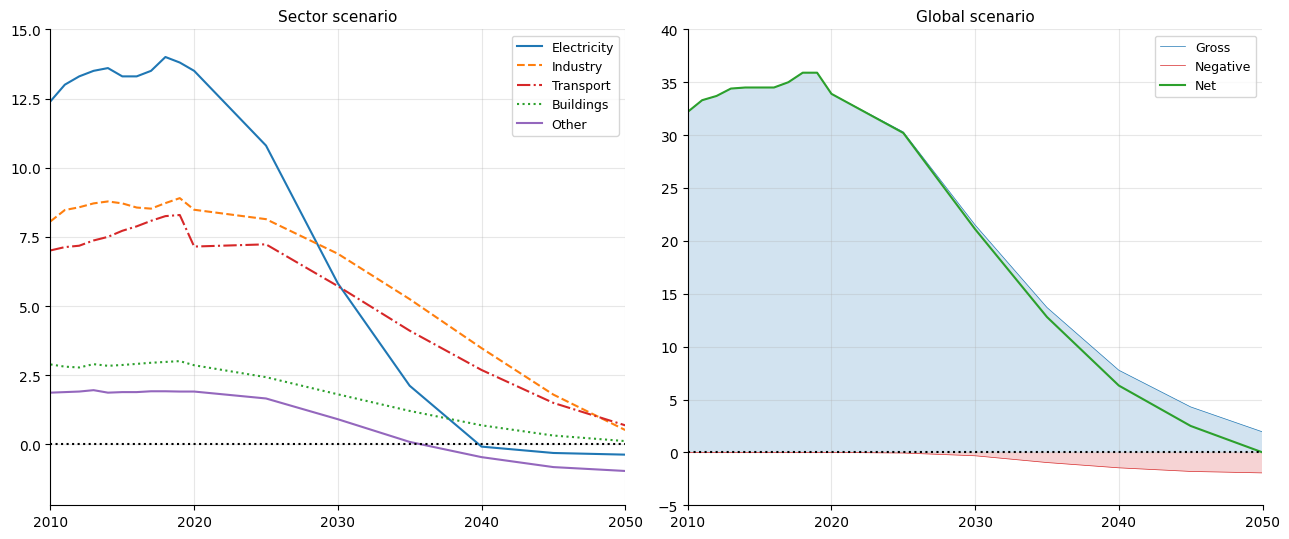

In [2]:
year1 = np.array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                   2020, 2025, 2030, 2035, 2040, 2045, 2050])
gross1 = np.array([32.20, 33.30, 33.70, 34.40, 34.50, 34.50, 34.50, 35.00, 35.90, 35.90,
                    33.90, 30.30, 21.50, 13.70, 7.77, 4.30, 1.94])
negative1 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.06, -0.32, -0.96, -1.46, -1.80, -1.94])
net1 = np.array([32.20, 33.30, 33.70, 34.40, 34.50, 34.50, 34.50, 35.00, 35.90, 35.90,
                  33.90, 30.20, 21.10, 12.80, 6.32, 2.50, 0.00])

sector_data = {
    "Electricity": [12.40, 13.00, 13.30, 13.50, 13.60, 13.30, 13.30, 13.50, 14.00, 13.80,
                    13.50, 10.80, 5.82, 2.12, -0.08, -0.31, -0.37],
    "Buildings": [2.89, 2.81, 2.78, 2.90, 2.84, 2.87, 2.91, 2.95, 2.98, 3.01,
                  2.86, 2.43, 1.81, 1.21, 0.69, 0.32, 0.12],
    "Transport": [7.01, 7.13, 7.18, 7.37, 7.50, 7.72, 7.88, 8.08, 8.25, 8.29,
                  7.15, 7.23, 5.72, 4.11, 2.69, 1.50, 0.69],
    "Industry": [8.06, 8.47, 8.57, 8.71, 8.78, 8.71, 8.56, 8.52, 8.72, 8.90,
                 8.48, 8.14, 6.89, 5.25, 3.48, 1.80, 0.52],
    "Other": [1.87, 1.89, 1.91, 1.96, 1.87, 1.89, 1.89, 1.92, 1.92, 1.91,
              1.91, 1.66, 0.91, 0.09, -0.46, -0.82, -0.96],
}
sector_order = ["Electricity", "Industry", "Transport", "Buildings", "Other"]
sector_styles = [("-", "tab:blue"), ("--", "tab:orange"), ("-.", "tab:red"), (":", "tab:green"), ("-", "tab:purple")]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
for name, (ls, c) in zip(sector_order, sector_styles):
    ax.plot(year1, sector_data[name], ls, color=c, linewidth=1.5, label=name)
ax.axhline(0, linestyle=":", color="black", linewidth=1.5)
ax.set_title("Sector scenario", fontsize=11)
ax.set_xlim(2010, 2050)
ax.set_xticks(range(2010, 2051, 10))
ax.set_ylim(-2.2, 15)
ax.set_yticks(np.arange(0, 15.1, 2.5))
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(year1, gross1, "-", color="tab:blue", linewidth=0.5)
ax.plot(year1, negative1, "-", color="tab:red", linewidth=0.5)
ax.plot(year1, net1, "-", color="tab:green", linewidth=1.5)
ax.axhline(0, linestyle=":", color="black", linewidth=1.5)
ax.fill_between(year1, gross1, 0, color="tab:blue", alpha=0.20, edgecolor="none")
ax.fill_between(year1, negative1, 0, color="tab:red", alpha=0.20, edgecolor="none")
ax.set_title("Global scenario", fontsize=11)
ax.set_xlim(2010, 2050)
ax.set_xticks(range(2010, 2051, 10))
ax.set_ylim(-5, 36)
ax.set_yticks(range(-5, 41, 5))
ax.legend(["Gross", "Negative", "Net"], fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Normalized pathway benchmarks: IEA / NZAOA / CTB / PAB (`net_zero1b`)

The global gross-emissions trajectory (IEA scenario), smoothed and
normalized to $100$ at 2020, compared against 3 stylized benchmarks: the
Net-Zero Asset Owner Alliance's (NZAOA) glide path, and the fixed 7%/year
Climate Transition Benchmark (CTB, 30% initial cut) and Paris-Aligned
Benchmark (PAB, 50% initial cut) trajectories.

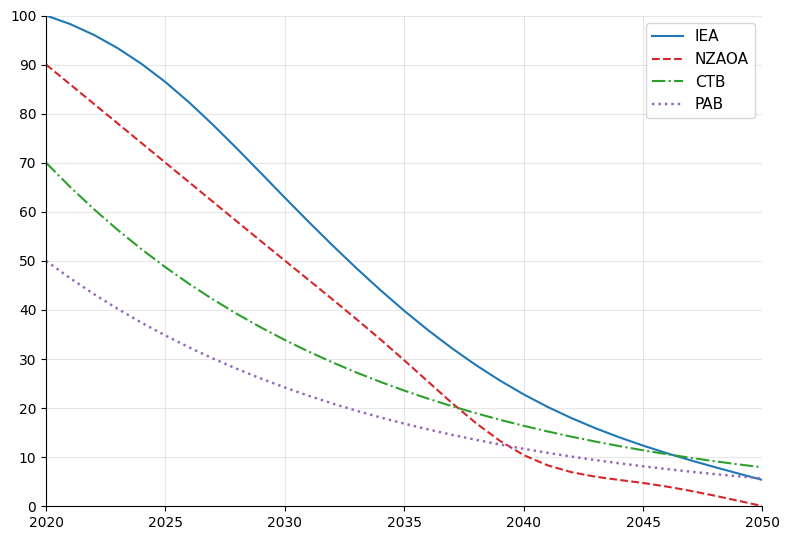

In [3]:
t, y_IEA, y_NZAOA, y_CTB, y_PAB = pathway_benchmarks()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(t, y_IEA, "-", color="tab:blue", linewidth=1.5, label="IEA")
ax.plot(t, y_NZAOA, "--", color="tab:red", linewidth=1.5, label="NZAOA")
ax.plot(t, y_CTB, "-.", color="tab:green", linewidth=1.5, label="CTB")
ax.plot(t, y_PAB, ":", color="tab:purple", linewidth=1.75, label="PAB")
ax.set_xlim(2020, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Reduction table at selected years (`net_zero1c`)

Same 4 benchmark curves as Section 2, expressed as a percentage
*reduction* from the 2020 level ($100-y$) and tabulated at 2020-2029
(annually) then every 5 years to 2050.

In [4]:
selected_t = np.concatenate([np.arange(2020, 2030), np.arange(2030, 2051, 5)])
idx = np.searchsorted(t, selected_t)
table = pd.DataFrame({
    "Year": selected_t,
    "CTB": 100 - y_CTB[idx],
    "PAB": 100 - y_PAB[idx],
    "IEA": 100 - y_IEA[idx],
    "NZAOA": 100 - y_NZAOA[idx],
})
display(table.round(1))

,Year,CTB,PAB,IEA,NZAOA
0,2020,30.0,50.0,0.0,10.0
1,2021,34.9,53.5,1.7,14.0
2,2022,39.5,56.8,3.9,18.0
3,2023,43.7,59.8,6.7,22.0
4,2024,47.6,62.6,9.9,26.0
5,2025,51.3,65.2,13.6,30.0
6,2026,54.7,67.7,17.8,34.0
7,2027,57.9,69.9,22.3,38.0
8,2028,60.8,72.0,27.2,42.0
9,2029,63.6,74.0,32.1,46.0


## 4. Sector-level pathway benchmarks (`net_zero1d`)

The same 5 sector trajectories from Section 1, each independently
smoothed and normalized to 100 at 2020 (only the first 4 — Electricity,
Industry, Transport, Buildings — are plotted, matching the source, which
computes "Other" but doesn't include it in the legend/figure). This is
also where the source saves `results/sector_iea.mat` for later reuse
(by `net_zero12`, per `chapter11_scoping.md`) — reproduced here as
`sector_iea_t`/`sector_iea_y` in memory rather than a file, since nothing
in this notebook needs to persist it to disk.

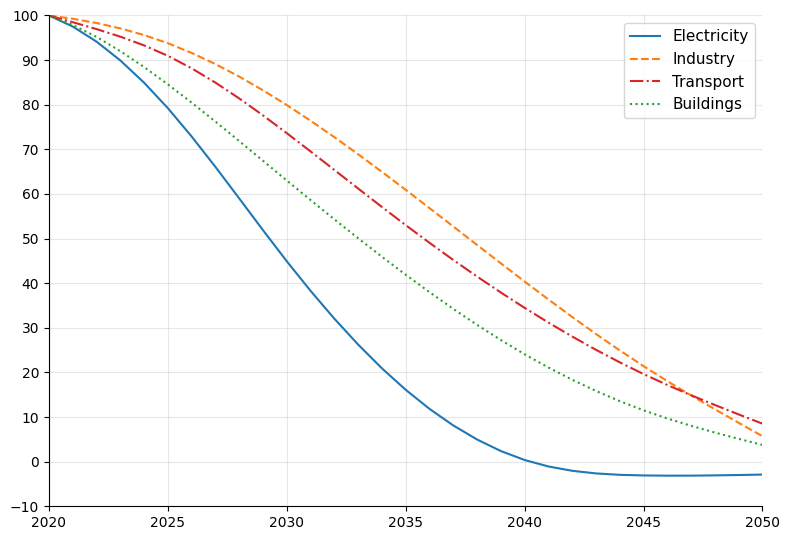

In [5]:
sector_order_full = ["Electricity", "Industry", "Transport", "Buildings", "Other"]
data2 = np.column_stack([sector_data[s] for s in sector_order_full])
idx2020 = np.where(year1 == 2020)[0][0]
data2_norm = 100 * data2 / data2[idx2020, :]

t_sector = np.arange(2020, 2051)
y_sector = np.column_stack([csaps(year1, data2_norm[:, j], t_sector, smooth=0.1) for j in range(5)])
y_sector_IEA = 100 * y_sector / y_sector[0, :]

sector_iea_t, sector_iea_y = t_sector, y_sector_IEA  # what the source persists to sector_iea.mat

fig, ax = plt.subplots(figsize=(8, 5.5))
styles4 = [("-", "tab:blue"), ("--", "tab:orange"), ("-.", "tab:red"), (":", "tab:green")]
for j, (name, (ls, c)) in enumerate(zip(sector_order_full[:4], styles4)):
    ax.plot(t_sector, y_sector_IEA[:, j], ls, color=c, linewidth=1.5, label=name)
ax.set_xlim(2020, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.set_ylim(-5, 100)
ax.set_yticks(range(-10, 101, 10))
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Advanced vs. developing economies: emissions and intensity (`net_zero8`)

Carbon emissions (CE) and carbon intensity (CI) trajectories for advanced
vs. developing economies, 2010-2050, each smoothed and normalized to 100
at 2020, on a finer 0.1-year grid.

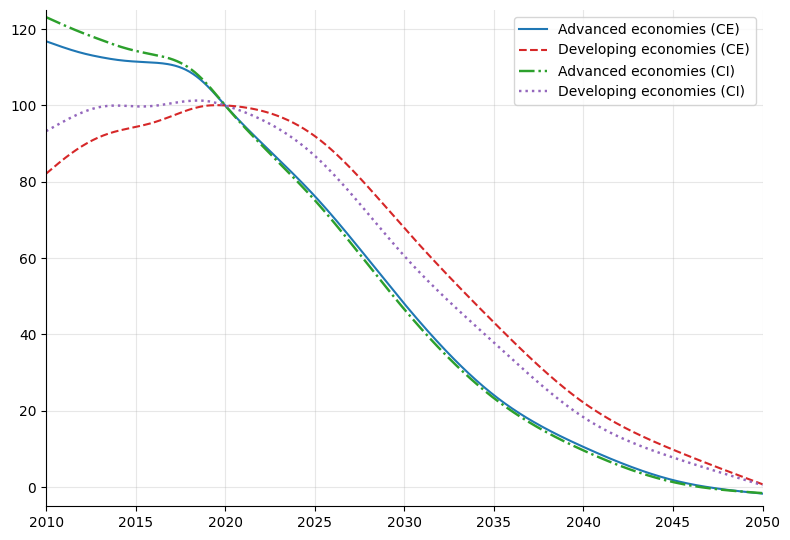

In [6]:
year8 = np.array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                   2020, 2025, 2030, 2035, 2040, 2045, 2050])
ce_adv = np.array([13423, 13193, 12949, 12991, 12759, 12721, 12663, 12664, 12746, 12312,
                    11057, 8793, 5494, 2737, 1232, 196, -183])
ce_dev = np.array([18810, 20090, 20757, 21434, 21788, 21738, 21857, 22348, 23122, 23614,
                    22846, 21442, 15653, 10048, 5084, 2303, 183])
ci_adv = np.array([10.1, 9.9, 9.7, 9.7, 9.4, 9.3, 9.2, 9.2, 9.2, 8.8,
                    7.91, 6.2, 3.8, 1.9, 0.8, 0.1, -0.12])
ci_dev = np.array([3.4, 3.5, 3.6, 3.7, 3.7, 3.6, 3.6, 3.7, 3.7, 3.8,
                    3.60, 3.2, 2.2, 1.4, 0.66, 0.29, 0.02])
data8 = np.column_stack([ce_adv, ce_dev, ci_adv, ci_dev])
idx2020_8 = np.where(year8 == 2020)[0][0]
data8_norm = 100 * data8 / data8[idx2020_8, :]

t8 = np.arange(2010, 2050.01, 0.1)
y8 = np.column_stack([csaps(year8, data8_norm[:, j], t8, smooth=0.4) for j in range(4)])
idx2020_t8 = np.argmin(np.abs(t8 - 2020))
y8 = 100 * y8 / y8[idx2020_t8, :]

fig, ax = plt.subplots(figsize=(8, 5.5))
labels8 = ["Advanced economies (CE)", "Developing economies (CE)",
           "Advanced economies (CI)", "Developing economies (CI)"]
styles8 = [("-", "tab:blue"), ("--", "tab:red"), ("-.", "tab:green"), (":", "tab:purple")]
for j, (label, (ls, c)) in enumerate(zip(labels8, styles8)):
    ax.plot(t8, y8[:, j], ls, color=c, linewidth=1.5 if j < 2 else 1.75, label=label)
ax.set_xlim(2010, 2050)
ax.set_xticks(range(2010, 2051, 5))
ax.set_ylim(-5, 125)
ax.set_yticks(range(0, 131, 20))
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()